In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


In [ ]:

# =========================================================
# 2. CLONE REPOSITORY (Opsional)
# =========================================================
if not os.path.exists('/content/Sigaleh'):
    !git clone https://github.com/ZuperGilz/Sigaleh.git
else:
    print("✅ Folder Sigaleh sudah tersedia.")

✅ Folder Sigaleh sudah tersedia.


In [ ]:
# =========================================================
# 3. LOAD DATASET
# =========================================================
file_harga = 'data_harga_komoditas.csv'
file_cuaca = 'dataset_cuaca_padang_bukittinggi.csv'

try:
    df_harga = pd.read_csv(file_harga)
    df_cuaca = pd.read_csv(file_cuaca)

    print("✅ Dataset berhasil dimuat.")

except Exception as e:
    print("❌ Terjadi kesalahan saat memuat data:")
    print(e)

❌ Terjadi kesalahan saat memuat data:
[Errno 2] No such file or directory: 'data_harga_komoditas.csv'


In [ ]:
# =========================================================
# 4. DATA ASSESSMENT
# =========================================================

print("\n=================================================")
print("INFORMASI DATA HARGA")
print("=================================================")
print(df_harga.info())

print("\n=================================================")
print("INFORMASI DATA CUACA")
print("=================================================")
print(df_cuaca.info())

# ---------------------------------------------------------
# Mengecek Missing Value
# ---------------------------------------------------------
print("\n=================================================")
print("MISSING VALUE DATA HARGA")
print("=================================================")
print(df_harga.isnull().sum())

print("\n=================================================")
print("MISSING VALUE DATA CUACA")
print("=================================================")
print(df_cuaca.isnull().sum())

# ---------------------------------------------------------
# Mengecek Data Duplikat
# ---------------------------------------------------------
print("\n=================================================")
print("JUMLAH DATA DUPLIKAT")
print("=================================================")

print("Duplicate Data Harga :", df_harga.duplicated().sum())
print("Duplicate Data Cuaca :", df_cuaca.duplicated().sum())

# ---------------------------------------------------------
# Statistik Deskriptif
# ---------------------------------------------------------
print("\n=================================================")
print("STATISTIK DESKRIPTIF DATA HARGA")
print("=================================================")

display(df_harga.describe())

print("\n=================================================")
print("STATISTIK DESKRIPTIF DATA CUACA")
print("=================================================")

display(df_cuaca.describe())


INFORMASI DATA HARGA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94830 entries, 0 to 94829
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Komoditas (Rp)     94830 non-null  object        
 1   Tanggal            94830 non-null  datetime64[ns]
 2   Harga              94830 non-null  float64       
 3   Wilayah            94830 non-null  object        
 4   Bulan              94830 non-null  int32         
 5   Tahun              94830 non-null  int32         
 6   Hari_Dalam_Minggu  94830 non-null  int32         
 7   Musim_Hujan        94830 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(2)
memory usage: 4.7+ MB
None

INFORMASI DATA CUACA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4624 entries, 0 to 4623
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   -----

,Tanggal,Harga,Bulan,Tahun,Hari_Dalam_Minggu,Musim_Hujan
count,94830,94830.000000,94830.000000,94830.000000,94830.000000,94830.000000
mean,2023-02-19 04:48:00,38052.697722,6.341284,2022.650765,2.000000,0.516208
min,2020-01-02 00:00:00,9450.000000,1.000000,2020.000000,0.000000,0.000000
25%,2021-07-27 00:00:00,16000.000000,3.000000,2021.000000,1.000000,0.000000
50%,2023-02-20 00:00:00,23200.000000,6.000000,2023.000000,2.000000,1.000000
75%,2024-09-13 00:00:00,40750.000000,9.000000,2024.000000,3.000000,1.000000
max,2026-04-08 00:00:00,160000.000000,12.000000,2026.000000,4.000000,1.000000
std,NaN,37443.678509,3.493093,1.815604,1.414221,0.499740



STATISTIK DESKRIPTIF DATA CUACA


,Tanggal,Suhu_Rata2_C,Curah_Hujan_mm,Radiasi_Matahari_MJm2,Kecepatan_Angin_Max_kmh
count,4624,4624.000000,4624.000000,4624.000000,4624.000000
mean,2023-03-01 12:00:00,23.644226,8.411743,17.431317,10.492128
min,2020-01-01 00:00:00,19.000000,0.000000,3.020000,4.200000
25%,2021-07-31 18:00:00,21.100000,1.000000,14.937500,8.200000
50%,2023-03-01 12:00:00,23.600000,4.200000,17.790000,9.700000
75%,2024-09-29 06:00:00,26.200000,11.000000,20.280000,12.025000
max,2026-04-30 00:00:00,29.000000,203.700000,28.050000,31.000000
std,NaN,2.680336,12.809642,4.008071,3.304867


In [ ]:
# =========================================================
# 5. DATA CLEANING
# =========================================================

# ---------------------------------------------------------
# Konversi Kolom Tanggal
# ---------------------------------------------------------
df_harga['Tanggal'] = pd.to_datetime(df_harga['Tanggal'])
df_cuaca['Tanggal'] = pd.to_datetime(df_cuaca['Tanggal'])


# ---------------------------------------------------------
# Menghapus Data Duplikat
# ---------------------------------------------------------
df_harga.drop_duplicates(inplace=True)
df_cuaca.drop_duplicates(inplace=True)

print("✅ Data duplikat berhasil dihapus.")

# ---------------------------------------------------------
# Membersihkan Spasi Berlebih
# ---------------------------------------------------------
df_harga['Wilayah'] = df_harga['Wilayah'].str.strip()
df_harga['Komoditas (Rp)'] = df_harga['Komoditas (Rp)'].str.strip()

# Urutkan data berdasarkan waktu terlebih dahulu agar ffill tidak salah ambil harga masa depan
df_harga = df_harga.sort_values(by=['Wilayah', 'Komoditas (Rp)', 'Tanggal'])

# Lakukan ffill per kelompok komoditas dan wilayah
df_harga['Harga'] = df_harga.groupby(['Wilayah', 'Komoditas (Rp)'])['Harga'].ffill()

# Jika masih ada NaN di baris paling pertama, kita bisa drop atau bfill
df_harga = df_harga.dropna(subset=['Harga'])

df_harga['Bulan'] = df_harga['Tanggal'].dt.month
df_harga['Tahun'] = df_harga['Tanggal'].dt.year
df_harga['Hari_Dalam_Minggu'] = df_harga['Tanggal'].dt.dayofweek # 0=Senin, 6=Minggu

# Tambahkan domain knowledge: Musim Hujan di Indonesia (Oktober - Maret)
df_harga['Musim_Hujan'] = df_harga['Bulan'].apply(lambda x: 1 if x in [10, 11, 12, 1, 2, 3] else 0)

print("✅ Data Cleaning selesai. Forward Fill dan Fitur Kalender telah diterapkan.")
display(df_harga[['Tanggal', 'Harga', 'Bulan', 'Tahun', 'Musim_Hujan']].head())


✅ Data duplikat berhasil dihapus.
✅ Data Cleaning selesai. Forward Fill dan Fitur Kalender telah diterapkan.


,Tanggal,Harga,Bulan,Tahun,Musim_Hujan
0,2020-01-02,31000.0,1,2020,1
1,2020-01-03,31000.0,1,2020,1
2,2020-01-06,31000.0,1,2020,1
3,2020-01-07,31500.0,1,2020,1
4,2020-01-08,32250.0,1,2020,1


In [ ]:
# =========================================================
# 6. VALIDASI HASIL CLEANING
# =========================================================

print("\n=================================================")
print("VALIDASI HASIL CLEANING")
print("=================================================")

print("\nMissing Value Data Harga:")
print(df_harga.isnull().sum())

print("\nMissing Value Data Cuaca:")
print(df_cuaca.isnull().sum())

print("\nDuplicate Data Harga:")
print(df_harga.duplicated().sum())

print("\nDuplicate Data Cuaca:")
print(df_cuaca.duplicated().sum())


VALIDASI HASIL CLEANING

Missing Value Data Harga:
Komoditas (Rp)       0
Tanggal              0
Harga                0
Wilayah              0
Bulan                0
Tahun                0
Hari_Dalam_Minggu    0
Musim_Hujan          0
dtype: int64

Missing Value Data Cuaca:
Wilayah                    0
Tanggal                    0
Suhu_Rata2_C               0
Curah_Hujan_mm             0
Radiasi_Matahari_MJm2      0
Kecepatan_Angin_Max_kmh    0
dtype: int64

Duplicate Data Harga:
0

Duplicate Data Cuaca:
0


In [ ]:
# =========================================================
# 7. MENAMPILKAN DATA
# =========================================================

print("\n=================================================")
print("5 DATA TERATAS DATA HARGA")
print("=================================================")

display(df_harga.head())

print("\n=================================================")
print("5 DATA TERATAS DATA CUACA")
print("=================================================")

display(df_cuaca.head())


5 DATA TERATAS DATA HARGA


,Komoditas (Rp),Tanggal,Harga,Wilayah,Bulan,Tahun,Hari_Dalam_Minggu,Musim_Hujan
0,Bawang Merah,2020-01-02,31000.0,Bukittinggi,1,2020,3,1
1,Bawang Merah,2020-01-03,31000.0,Bukittinggi,1,2020,4,1
2,Bawang Merah,2020-01-06,31000.0,Bukittinggi,1,2020,0,1
3,Bawang Merah,2020-01-07,31500.0,Bukittinggi,1,2020,1,1
4,Bawang Merah,2020-01-08,32250.0,Bukittinggi,1,2020,2,1



5 DATA TERATAS DATA CUACA


,Wilayah,Tanggal,Suhu_Rata2_C,Curah_Hujan_mm,Radiasi_Matahari_MJm2,Kecepatan_Angin_Max_kmh
0,Padang,2020-01-01,27.3,9.5,18.55,8.4
1,Padang,2020-01-02,27.7,2.9,21.86,9.2
2,Padang,2020-01-03,26.6,13.9,16.96,7.8
3,Padang,2020-01-04,26.7,8.3,19.58,7.2
4,Padang,2020-01-05,27.0,7.6,18.90,9.7


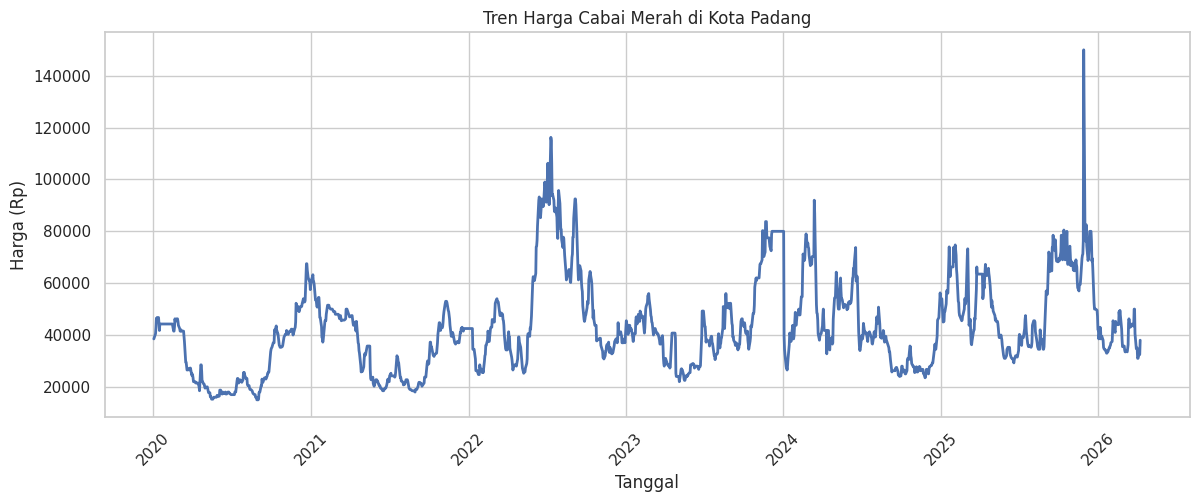

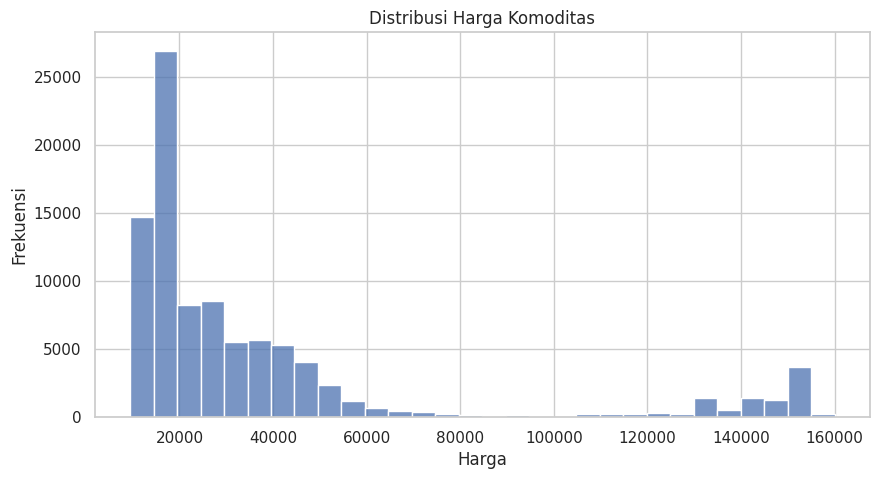

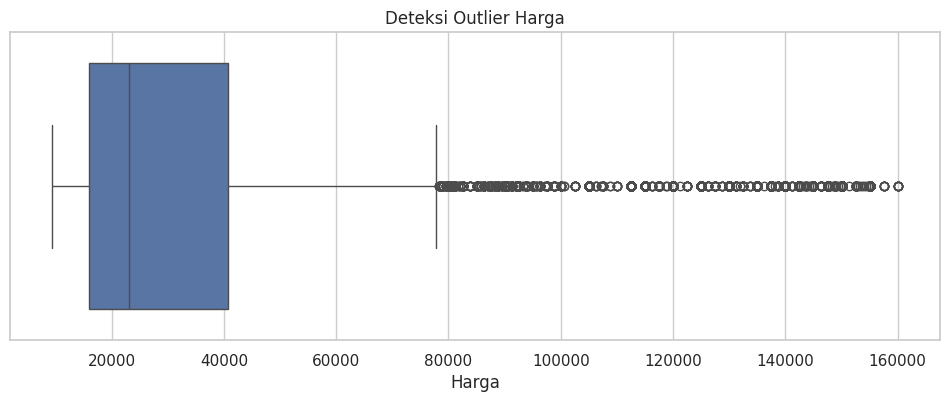

In [ ]:
# =========================================================
# 8. VISUALISASI DATA
# =========================================================

# ---------------------------------------------------------
# Visualisasi Tren Harga Cabai Merah
# ---------------------------------------------------------
data_plot = df_harga[
    (df_harga['Komoditas (Rp)'] == 'Cabai Merah') &
    (df_harga['Wilayah'] == 'Padang')
]

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=data_plot,
    x='Tanggal',
    y='Harga',
    linewidth=2
)

plt.title('Tren Harga Cabai Merah di Kota Padang')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# ---------------------------------------------------------
# Visualisasi Distribusi Harga
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

sns.histplot(df_harga['Harga'], bins=30)

plt.title('Distribusi Harga Komoditas')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')

plt.show()

# ---------------------------------------------------------
# Visualisasi Outlier Harga
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

sns.boxplot(x=df_harga['Harga'])

plt.title('Deteksi Outlier Harga')

plt.show()

In [ ]:
# =========================================================
# 9. MERGE DATA HARGA & CUACA
# =========================================================

try:
    merged_df = pd.merge(
        df_harga,
        df_cuaca,
        on=['Tanggal', 'Wilayah'],
        how='inner'
    )

    print("\n✅ Data berhasil digabungkan.")

    print("\nUkuran Data Setelah Merge:")
    print(merged_df.shape)

except Exception as e:
    print("\n❌ Gagal melakukan merge data:")
    print(e)


✅ Data berhasil digabungkan.

Ukuran Data Setelah Merge:
(94830, 12)


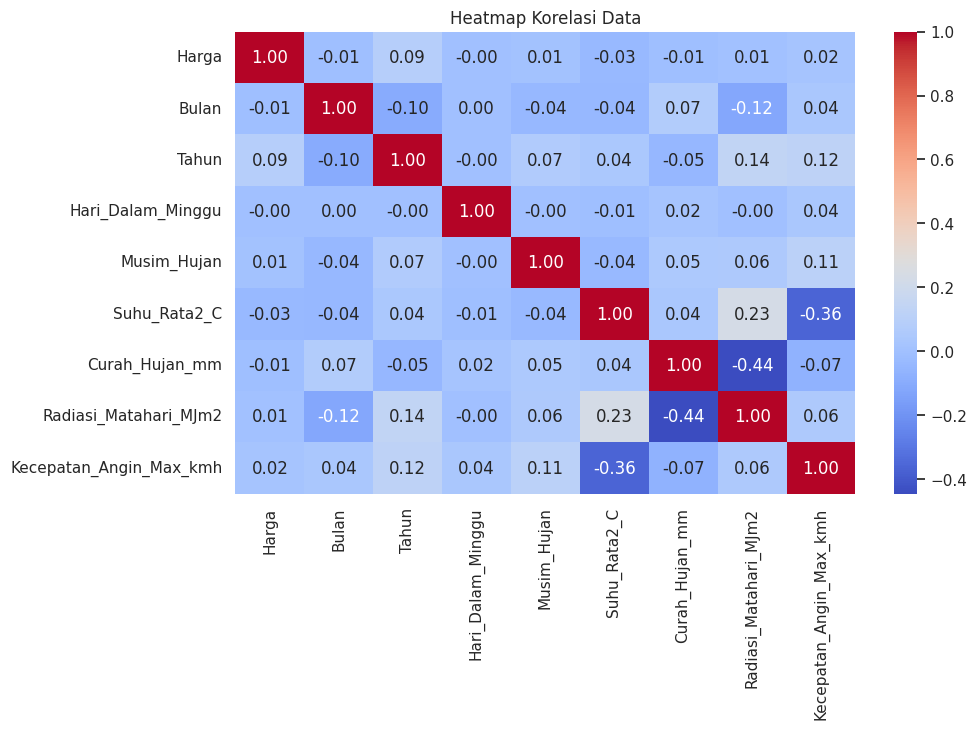

In [ ]:
# =========================================================
# 10. ANALISIS KORELASI
# =========================================================

plt.figure(figsize=(10, 6))

corr = merged_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Data')

plt.show()

In [ ]:
df_harga.nunique()

,0
Komoditas (Rp),29
Tanggal,1635
Harga,1134
Wilayah,2
Bulan,12
Tahun,7
Hari_Dalam_Minggu,5
Musim_Hujan,2


In [ ]:
# Asumsi: df_harga dan df_cuaca sudah dibersihkan (pakai ffill & punya kolom kalender)
# =========================================================
# 1. MERGE DATA (HARGA + CUACA)
# =========================================================
# Gabungkan kembali data yang sudah bersih
df_merged = pd.merge(df_harga, df_cuaca, on=['Tanggal', 'Wilayah'], how='inner')

# SANGAT PENTING: Urutkan secara kronologis sebelum membuat Lag/Rolling
df_merged = df_merged.sort_values(by=['Wilayah', 'Komoditas (Rp)', 'Tanggal']).reset_index(drop=True)

print("Mulai proses Feature Engineering...")

# =========================================================
# 2. FUNGSI FEATURE ENGINEERING
# =========================================================
def buat_fitur_timeseries(group):
    # --- A. Fitur Jeda Waktu (Lagging) untuk Cuaca ---
    # Melihat kondisi cuaca 1 bulan (30 hari) dan 2 bulan (60 hari) yang lalu
    group['Hujan_Lag30'] = group['Curah_Hujan_mm'].shift(30)
    group['Hujan_Lag60'] = group['Curah_Hujan_mm'].shift(60)

    group['Suhu_Lag30'] = group['Suhu_Rata2_C'].shift(30)
    group['Suhu_Lag60'] = group['Suhu_Rata2_C'].shift(60)

    # --- B. Fitur Rata-rata Bergerak (Rolling Mean) untuk Cuaca ---
    # Melihat akumulasi rata-rata cuaca selama 30 hari terakhir
    group['Rata_Hujan_30Hari'] = group['Curah_Hujan_mm'].rolling(window=30, min_periods=1).mean()
    group['Rata_Suhu_30Hari'] = group['Suhu_Rata2_C'].rolling(window=30, min_periods=1).mean()

    # --- C. Fitur Lag Harga (Bonus untuk mempermudah LSTM nanti) ---
    # Harga kemarin dan harga seminggu yang lalu sangat berpengaruh ke harga hari ini
    group['Harga_Kemarin'] = group['Harga'].shift(1)
    group['Harga_Minggu_Lalu'] = group['Harga'].shift(7)

    return group

# =========================================================
# 3. APPLY FE KE DATASET
# =========================================================
# Terapkan fungsi di atas per kelompok Wilayah dan Komoditas agar pergeserannya tidak menyeberang
df_fe = df_merged.groupby(['Wilayah', 'Komoditas (Rp)']).apply(buat_fitur_timeseries).reset_index(drop=True)

# Karena kita melakukan shift sejauh 60 hari, 60 baris pertama tiap komoditas akan menjadi NaN (kosong).
# Kita harus menghapusnya agar korelasi bisa dihitung.
df_fe = df_fe.dropna()

print("\n✅ Feature Engineering selesai!")
print("Dimensi data baru:", df_fe.shape)
print("\nContoh kolom baru yang terbentuk:")
display(df_fe[['Tanggal', 'Komoditas (Rp)', 'Harga', 'Hujan_Lag30', 'Rata_Hujan_30Hari', 'Harga_Kemarin']].head())

# Simpan data yang sudah di-FE
df_fe.to_csv('dataset_sigaleh_Final.csv', index=False)

Mulai proses Feature Engineering...

✅ Feature Engineering selesai!
Dimensi data baru: (91350, 20)

Contoh kolom baru yang terbentuk:


/tmp/ipykernel_9451/2307094423.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fe = df_merged.groupby(['Wilayah', 'Komoditas (Rp)']).apply(buat_fitur_timeseries).reset_index(drop=True)


,Tanggal,Komoditas (Rp),Harga,Hujan_Lag30,Rata_Hujan_30Hari,Harga_Kemarin
60,2020-03-26,Bawang Merah,31000.0,26.6,8.666667,31000.0
61,2020-03-27,Bawang Merah,33500.0,23.9,8.056667,31000.0
62,2020-03-30,Bawang Merah,33500.0,12.8,8.350000,33500.0
63,2020-03-31,Bawang Merah,36000.0,10.5,8.066667,33500.0
64,2020-04-01,Bawang Merah,36000.0,7.7,8.250000,36000.0


In [ ]:
df_fe.head()

,Komoditas (Rp),Tanggal,Harga,Wilayah,Bulan,Tahun,Hari_Dalam_Minggu,Musim_Hujan,Suhu_Rata2_C,Curah_Hujan_mm,Radiasi_Matahari_MJm2,Kecepatan_Angin_Max_kmh,Hujan_Lag30,Hujan_Lag60,Suhu_Lag30,Suhu_Lag60,Rata_Hujan_30Hari,Rata_Suhu_30Hari,Harga_Kemarin,Harga_Minggu_Lalu
60,Bawang Merah,2020-03-26,31000.0,Bukittinggi,3,2020,3,1,21.1,20.1,16.55,10.9,26.6,0.7,21.2,20.7,8.666667,21.186667,31000.0,31000.0
61,Bawang Merah,2020-03-27,33500.0,Bukittinggi,3,2020,4,1,21.3,5.6,19.03,9.7,23.9,4.0,21.0,20.8,8.056667,21.196667,31000.0,31000.0
62,Bawang Merah,2020-03-30,33500.0,Bukittinggi,3,2020,0,1,21.8,21.6,18.10,12.0,12.8,1.1,20.9,20.9,8.350000,21.226667,33500.0,32750.0
63,Bawang Merah,2020-03-31,36000.0,Bukittinggi,3,2020,1,1,21.2,2.0,16.47,6.5,10.5,7.6,20.7,20.8,8.066667,21.243333,33500.0,32250.0
64,Bawang Merah,2020-04-01,36000.0,Bukittinggi,4,2020,2,0,21.0,13.2,16.34,8.2,7.7,1.0,19.6,20.9,8.250000,21.290000,36000.0,31000.0
